# Synthetic advection initializer benchmark (081526)

목표는 full seven-parameter fitting 전에 advection initial point를 빠르고 안정적으로 정하는 것이다. Known-truth synthetic data에서 M0--M5를 비교하고, 선택된 advection으로 corridor geometry를 한 번만 만든 뒤 downstream fit 중에는 corridor를 고정한다.

- **M0**: zero seed baseline
- **M1**: max-min 400 points/hour, advection-only L-BFGS 1 call, `max_eval=20`
- **M2**: max-min 300 points/hour, four quadrant starts, each `max_eval=5`
- **M3**: pair-count-filtered, smoothed empirical cross-semivariogram ridge at $\tau=1$
- **M4**: polar profile (8 angles x 3 magnitudes) + local `max_eval=5` refinement
- **M5**: oracle true-advection seed

Initializer comparison uses three independent synthetic days. The downstream full fit uses the first day only to keep the benchmark fast.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
HERE = REPO / 'Exercises/st_model/day/amarel_simulation/space_time/real_data/advection_direction'
DRIVER = HERE / 'synthetic_advection_initializer_benchmark_corridor432_081526.py'
OUT = REPO / 'outputs/summer_26/synthetic_advection_initializer_benchmark_corridor432_081526'

init = pd.read_csv(OUT / 'initializer_results.csv')
full = pd.read_csv(OUT / 'full_fit_results.csv')
quadrant = pd.read_csv(OUT / 'quadrant_candidates.csv')
polar = pd.read_csv(OUT / 'polar_profile_candidates.csv')
config = json.loads((OUT / 'run_config.json').read_text())
runtime = json.loads((OUT / 'total_runtime.json').read_text())

print(f'initializer rows={len(init)}, full-fit rows={len(full)}')
print(f"all initializer status ok: {init['status'].eq('ok').all()}")
print(f"all full-fit status ok: {full['status'].eq('ok').all()}")
print(f"total benchmark wall time: {runtime['benchmark_wall_s']:.2f} s ({runtime['benchmark_wall_minutes']:.2f} min)")

initializer rows=108, full-fit rows=6
all initializer status ok: True
all full-fit status ok: True
total benchmark wall time: 193.63 s (3.23 min)


## Experimental controls

The initializer stage deliberately prevents nuisance parameters from winning the comparison by moving first. We run oracle-fixed nuisance, joint nuisance misspecification at $-50\%$, $-25\%$, $+25\%$, and $+50\%$, and a partial-free ablation that releases `range_time` with advection. In the downstream fit, all seven parameters are free, nuisance starts are identical across methods, and only the advection seed/corridor differs.

In [2]:
pd.Series({
    'truth': config['truth'],
    'days': config['days'],
    'full_fit_days': config['full_fit_days'],
    'lat_range': config['lat_range'],
    'lon_range': config['lon_range'],
    'pilot400_points/hour': config['arguments']['pilot400_points'],
    'pilot300_points/hour': config['arguments']['pilot300_points'],
    'final_outer_steps': config['arguments']['final_outer_steps'],
    'final_max_eval': config['arguments']['final_max_eval'],
})

truth                   {'advec_lat': 0.08, 'advec_lon': -0.2, 'nugget...
days                                                            [0, 1, 2]
full_fit_days                                                         [0]
lat_range                                                    [-3.0, -1.0]
lon_range                                                  [121.0, 125.0]
pilot400_points/hour                                                  400
pilot300_points/hour                                                  300
final_outer_steps                                                       1
final_max_eval                                                         10
dtype: object

## 1. Oracle-nuisance initializer accuracy and runtime

In [3]:
oracle = init.query("scenario == 'oracle_fixed'").copy()
oracle_summary = (oracle.groupby('method', sort=False)
    .agg(n_days=('day', 'nunique'),
         mean_error=('seed_error_euclid', 'mean'),
         median_error=('seed_error_euclid', 'median'),
         mean_angle_deg=('seed_angle_error_deg', 'mean'),
         mean_time_s=('seed_total_s', 'mean'),
         mean_closures=('closure_calls', 'mean'),
         quadrant_rate=('correct_quadrant', 'mean')))
display(oracle_summary.style.format({
    'mean_error': '{:.5f}', 'median_error': '{:.5f}',
    'mean_angle_deg': '{:.2f}', 'mean_time_s': '{:.3f}',
    'mean_closures': '{:.1f}', 'quadrant_rate': '{:.0%}',
}))

,n_days,mean_error,median_error,mean_angle_deg,mean_time_s,mean_closures,quadrant_rate
method,,,,,,,
M0_zero,3,0.21541,0.21541,nan,0.000,0.0,0%
M1_pilot400,3,0.02092,0.02177,3.63,1.783,7.0,100%
M2_quadrant300,3,0.01837,0.02191,4.10,3.667,20.7,100%
M3_empirical,3,0.01360,0.01360,3.17,0.148,0.0,100%
M4_polar_profile,3,0.01860,0.02206,4.18,2.091,5.0,100%
M5_oracle,3,0.00000,0.00000,0.00,0.000,0.0,100%


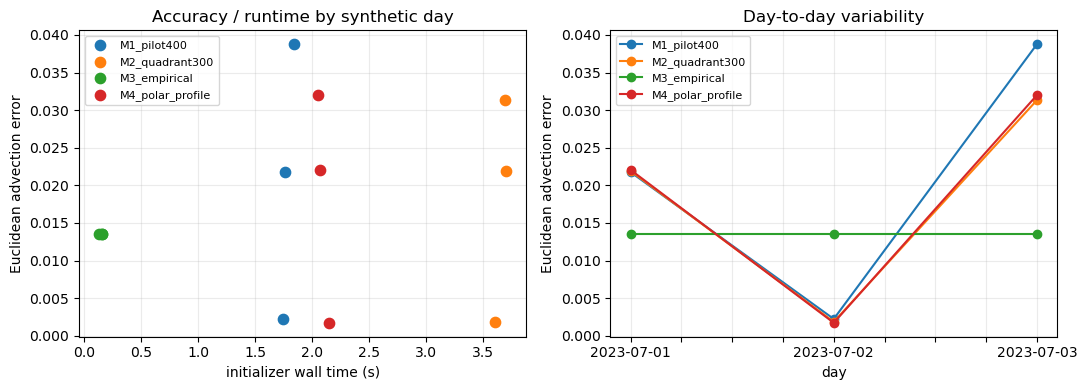

In [4]:
plot_df = oracle.query("method not in ['M0_zero', 'M5_oracle']")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for method, group in plot_df.groupby('method', sort=False):
    axes[0].scatter(group['seed_total_s'], group['seed_error_euclid'], s=55, label=method)
axes[0].set(xlabel='initializer wall time (s)', ylabel='Euclidean advection error',
            title='Accuracy / runtime by synthetic day')
axes[0].grid(alpha=.25); axes[0].legend(fontsize=8)

per_day = oracle.pivot(index='day', columns='method', values='seed_error_euclid')
per_day[['M1_pilot400', 'M2_quadrant300', 'M3_empirical', 'M4_polar_profile']].plot(
    ax=axes[1], marker='o')
axes[1].set(ylabel='Euclidean advection error', title='Day-to-day variability')
axes[1].grid(alpha=.25); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. Nuisance robustness

M3 is data-driven and therefore unchanged by nuisance starting values. For likelihood methods, the table measures how much the seed shifts when covariance nuisance values are wrong or `range_time` is jointly released.

In [5]:
method_order = ['M1_pilot400', 'M2_quadrant300', 'M3_empirical', 'M4_polar_profile']
scenario_order = ['oracle_fixed', 'nuisance_minus50', 'nuisance_minus25',
                  'nuisance_plus25', 'nuisance_plus50', 'partial_free_range_time']
robust = (init[init['method'].isin(method_order)]
          .groupby(['scenario', 'method'])
          .agg(mean_error=('seed_error_euclid', 'mean'),
               mean_angle_deg=('seed_angle_error_deg', 'mean'),
               mean_time_s=('seed_total_s', 'mean'))
          .reset_index())
err_table = robust.pivot(index='scenario', columns='method', values='mean_error').reindex(scenario_order)[method_order]
display(err_table.style.format('{:.5f}').background_gradient(cmap='YlGn_r', axis=None))
display(robust.pivot(index='scenario', columns='method', values='mean_time_s').reindex(scenario_order)[method_order]
        .style.format('{:.3f}'))

method,M1_pilot400,M2_quadrant300,M3_empirical,M4_polar_profile
scenario,,,,
oracle_fixed,0.02092,0.01837,0.01360,0.01860
nuisance_minus50,0.03957,0.04411,0.01360,0.04465
nuisance_minus25,0.02360,0.02160,0.01360,0.02215
nuisance_plus25,0.02155,0.02019,0.01360,0.02025
nuisance_plus50,0.02416,0.02408,0.01360,0.02432
partial_free_range_time,0.02140,0.02691,0.01360,0.02810


method,M1_pilot400,M2_quadrant300,M3_empirical,M4_polar_profile
scenario,,,,
oracle_fixed,1.783,3.667,0.148,2.091
nuisance_minus50,1.766,3.713,0.148,2.078
nuisance_minus25,1.750,3.684,0.148,2.011
nuisance_plus25,1.683,3.572,0.148,2.103
nuisance_plus50,1.621,3.598,0.148,2.087
partial_free_range_time,2.882,3.743,0.148,2.113


## 3. Candidate-selection diagnostics

M2 must select by the re-evaluated NLL after each short run, not by the quadrant label. M4 separates the coarse polar profile from the local refinement.

In [6]:
qcols = [c for c in ['day', 'scenario', 'start_lat', 'start_lon', 'fit_lat', 'fit_lon',
                         'reevaluated_nll', 'selected', 'elapsed_s', 'closure_calls'] if c in quadrant]
display(quadrant.query("scenario == 'oracle_fixed'")[qcols].head(12))
pcols = [c for c in ['day', 'scenario', 'angle_deg', 'magnitude', 'candidate_lat', 'candidate_lon',
                         'profile_nll', 'selected'] if c in polar]
display(polar.query("scenario == 'oracle_fixed'")[pcols].head(24))

,day,scenario,start_lat,start_lon,selected,closure_calls
0,2023-07-01,oracle_fixed,0.01,0.1,False,6
1,2023-07-01,oracle_fixed,0.01,-0.1,False,5
2,2023-07-01,oracle_fixed,-0.01,-0.1,True,5
3,2023-07-01,oracle_fixed,-0.01,0.1,False,5
24,2023-07-02,oracle_fixed,0.01,0.1,False,5
25,2023-07-02,oracle_fixed,0.01,-0.1,True,5
26,2023-07-02,oracle_fixed,-0.01,-0.1,False,5
27,2023-07-02,oracle_fixed,-0.01,0.1,False,5
48,2023-07-03,oracle_fixed,0.01,0.1,False,6
49,2023-07-03,oracle_fixed,0.01,-0.1,False,5


,day,scenario,profile_nll,selected
0,2023-07-01,oracle_fixed,1.555492,False
1,2023-07-01,oracle_fixed,1.546939,False
2,2023-07-01,oracle_fixed,1.534428,False
3,2023-07-01,oracle_fixed,1.526939,False
4,2023-07-01,oracle_fixed,1.533972,False
5,2023-07-01,oracle_fixed,1.543735,False
6,2023-07-01,oracle_fixed,1.551171,False
7,2023-07-01,oracle_fixed,1.554962,False
8,2023-07-01,oracle_fixed,1.558692,False
9,2023-07-01,oracle_fixed,1.561670,False


## 4. Downstream seven-parameter fit

This is the decisive end-to-end check. Every method gets the same nuisance start and one L-BFGS outer call with `max_eval=10`. The method-specific advection initializes both the parameters and a fixed directional lag-432 corridor; the corridor is not rebuilt during fitting.

In [7]:
full_view = full[[
    'method', 'seed_error_euclid', 'final_seed_error_euclid', 'final_nll',
    'final_rmsre_7param', 'seed_total_s', 'final_total_s', 'end_to_end_s',
    'est_advec_lat', 'est_advec_lon', 'final_closure_calls', 'status'
]].rename(columns={'final_seed_error_euclid': 'final_advection_error'})
display(full_view.style.format({
    'seed_error_euclid': '{:.5f}', 'final_advection_error': '{:.5f}',
    'final_nll': '{:.6f}', 'final_rmsre_7param': '{:.5f}',
    'seed_total_s': '{:.3f}', 'final_total_s': '{:.3f}', 'end_to_end_s': '{:.3f}',
    'est_advec_lat': '{:.5f}', 'est_advec_lon': '{:.5f}',
}))

,method,seed_error_euclid,final_advection_error,final_nll,final_rmsre_7param,seed_total_s,final_total_s,end_to_end_s,est_advec_lat,est_advec_lon,final_closure_calls,status
0,M0_zero,0.21541,0.01256,1.128375,0.03617,0.000,7.512,7.512,0.07586,-0.18814,10,ok
1,M1_pilot400,0.02177,0.00438,1.123227,0.03088,1.758,7.565,9.323,0.07581,-0.20125,10,ok
2,M2_quadrant300,0.02191,0.00446,1.123241,0.02499,3.701,7.658,11.358,0.07556,-0.20039,10,ok
3,M3_empirical,0.01360,0.00473,1.122893,0.02495,0.159,7.595,7.755,0.07539,-0.19895,10,ok
4,M4_polar_profile,0.02206,0.00445,1.123241,0.02498,2.068,7.580,9.648,0.07557,-0.20041,10,ok
5,M5_oracle,0.00000,0.00393,1.122993,0.02152,0.000,7.684,7.684,0.07620,-0.19900,10,ok


## Interpretation

For this three-day synthetic benchmark, **M3 empirical is the practical winner**: mean initializer error is 0.01360, mean time is 0.148 s, and all days choose the correct quadrant. M1 is the best likelihood-based default (mean error 0.02092 in 1.783 s) and is cheaper than M2 or M4. M2 and M4 obtain similar mean errors (0.01837 and 0.01860), but cost 3.667 s and 2.091 s respectively.

The likelihood methods remain in the correct quadrant under every nuisance experiment, but their error increases most when all nuisance values are 50% too small. Releasing `range_time` does not improve this small-budget initializer; it is especially harmful for M2/M4. This supports keeping nuisance fixed during the main initializer comparison.

On the first-day downstream fit, all nonzero initializers converge to final advection error around 0.004--0.005. M3 has the best final NLL (1.122893) and the fastest non-oracle end-to-end time (7.755 s). Zero seed also moves close to truth, but its fixed zero-direction corridor gives a worse final NLL (1.128375), so learning direction before constructing the corridor is still useful.

The M3 result should be treated as promising rather than final proof: its grid-selected ridge is identical across these three days, and the benchmark uses one truth and one spatial subdomain. The next robustness extension should vary advection direction/magnitude and simulate more replicates before selecting a production default.

## Re-run command

The benchmark output already loaded above was produced with the following command. Set `RUN_EXPERIMENT=True` only when regenerating the CSVs.

In [8]:
RUN_EXPERIMENT = False
command = [
    '/opt/anaconda3/envs/faiss_env/bin/python', str(DRIVER),
    '--days', '0,3', '--full-fit-days', '0',
    '--lat-range=-3,-1', '--lon-range=121,125', '--device', 'cpu',
    '--output-root', str(OUT),
]
print(' '.join(command))
if RUN_EXPERIMENT:
    import subprocess
    subprocess.run(command, cwd=REPO, check=True)

/opt/anaconda3/envs/faiss_env/bin/python /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/amarel_simulation/space_time/real_data/advection_direction/synthetic_advection_initializer_benchmark_corridor432_081526.py --days 0,3 --full-fit-days 0 --lat-range=-3,-1 --lon-range=121,125 --device cpu --output-root /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/summer_26/synthetic_advection_initializer_benchmark_corridor432_081526
